
# NBA Shot Data — Holistic Exploration
This notebook helps you build a holistic understanding of NBA shot data using common visuals:
- Overview metrics
- Shot selection (2 vs 3), distance distribution
- Court shot chart (sampled)
- Player FG% leaders (with volume filter)
- FG% heatmap by (distance × shot clock)
- Team-level shot profiles (3PA rate vs FG%, bubble = avg distance)

**New sections added (as requested):**
- 3PA rate vs **team points per game** (field-goal points only)
- **Top 10 points-per-game players** (field-goal points only)
- **FG% (x-axis) vs Shots Attempted (y-axis)** (player-level)
- **Individual "bad shot" percentage** (share of shots that were contested)

**Notes**
- Uses only `matplotlib` for plotting (no seaborn), each chart in a single figure (no subplots).
- Works with the uploaded CSV schema (2013 enriched shots). You can point to other seasons later.
- Where the dataset lacks free throws, "points per game" here reflects **field-goal points only** computed from made shots × shot value.
- If columns are missing in other seasons, cells will gracefully skip those visuals.


In [3]:

# === 0. Setup & Load ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your uploaded file (adjust if needed)
FILE_PATH = "enriched_data/nba_savant_2013_enriched_shots_v2.csv"

shots = pd.read_csv(FILE_PATH)
print(f"Loaded {len(shots):,} shots with {shots.shape[1]} columns.")
shots.head(3)


Loaded 204,126 shots with 29 columns.


,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,defender_name,defender_distance,shot_clock,team,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons,shotValue
0,James Johnson,Memphis Grizzlies,2014-03-12,2013,3999.0,1610612763,400489836,4,11,30,...,"Miller, Darius",2.4,12.5,MEM,12.5,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
1,Jerryd Bayless,Memphis Grizzlies,2013-12-23,2013,3417.0,1610612763,400489286,2,8,27,...,"Burks, Alec",3.7,24.0,MEM,24.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
2,Tony Allen,Memphis Grizzlies,2014-03-19,2013,2367.0,1610612763,400489884,3,3,58,...,"Kanter, Enes",4.5,8.6,MEM,8.6,from_savant_shot_clock,1,borderline,location: at-rim/very close,2


In [4]:

# === 1. Quick Schema & Basic Hygiene ===
print(shots.dtypes)
missing_by_col = shots.isna().mean().sort_values(ascending=False)
print("\nMissing ratio by column (top 10):")
print(missing_by_col.head(10))

# Standardize a few expected columns if present
rename_map = {
    'team': 'team_name',
    'shot_distance': 'shot_distance',
    'shot_made_flag': 'shot_made_flag',
    'x': 'x', 'y': 'y',
    'shotValue': 'shotValue',
    'shot_clock': 'shot_clock',
}
# (no actual renames, just a place-holder pattern if needed later)
shots = shots.copy()
shots


name                  object
team_name             object
game_date             object
season                 int64
espn_player_id       float64
team_id                int64
espn_game_id           int64
period                 int64
minutes_remaining      int64
seconds_remaining      int64
shot_made_flag         int64
action_type           object
shot_type             object
shot_distance          int64
opponent              object
x                      int64
y                      int64
dribbles               int64
touch_time           float64
defender_name         object
defender_distance    float64
shot_clock           float64
team                  object
SHOT_CLOCK_APPROX    float64
SHOT_CLOCK_SOURCE     object
contest_score          int64
contest_label         object
contest_reasons       object
shotValue              int64
dtype: object

Missing ratio by column (top 10):
espn_player_id       0.009328
defender_name        0.007270
contest_reasons      0.001798
name                

,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,defender_name,defender_distance,shot_clock,team,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons,shotValue
0,James Johnson,Memphis Grizzlies,2014-03-12,2013,3999.0,1610612763,400489836,4,11,30,...,"Miller, Darius",2.4,12.5,MEM,12.5,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
1,Jerryd Bayless,Memphis Grizzlies,2013-12-23,2013,3417.0,1610612763,400489286,2,8,27,...,"Burks, Alec",3.7,24.0,MEM,24.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
2,Tony Allen,Memphis Grizzlies,2014-03-19,2013,2367.0,1610612763,400489884,3,3,58,...,"Kanter, Enes",4.5,8.6,MEM,8.6,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
3,Kosta Koufos,Memphis Grizzlies,2014-03-19,2013,3444.0,1610612763,400489884,4,10,54,...,"Williams, Marvin",8.3,14.1,MEM,14.1,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
4,Ed Davis,Memphis Grizzlies,2013-11-06,2013,4259.0,1610612763,400488938,4,8,48,...,"Stiemsma, Greg",7.8,19.6,MEM,19.6,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204121,Joakim Noah,Chicago Bulls,2013-11-18,2013,3224.0,1610612741,400489024,1,10,18,...,"Biyombo, Bismack",2.0,0.0,CHI,0.0,from_savant_shot_clock,3,likely_contested,"action: contested-like, action: open-like, loc...",2
204122,Taj Gibson,Chicago Bulls,2014-01-22,2013,3986.0,1610612741,400489495,3,10,1,...,"Varejao, Anderson",2.3,8.2,CHI,8.2,from_savant_shot_clock,2,likely_contested,"action: contested-like, action: open-like, loc...",2
204123,Joakim Noah,Chicago Bulls,2013-12-19,2013,3224.0,1610612741,400489254,3,5,27,...,"Ibaka, Serge",1.6,7.7,CHI,7.7,from_savant_shot_clock,2,likely_contested,"action: contested-like, action: open-like, loc...",2
204124,Taj Gibson,Chicago Bulls,2013-12-07,2013,3986.0,1610612741,400489165,1,11,17,...,"Smith, Josh",3.3,0.0,CHI,0.0,from_savant_shot_clock,3,likely_contested,"action: contested-like, action: open-like, loc...",2


## 2. Overview KPIs

In [5]:

total_shots = len(shots)
fg_pct = shots['shot_made_flag'].mean() if 'shot_made_flag' in shots else np.nan
seasons = shots['season'].dropna().unique() if 'season' in shots else []

print(f"Total shots: {total_shots:,}")
print(f"Overall FG%: {fg_pct:.2%}" if not np.isnan(fg_pct) else "Overall FG%: N/A")
print(f"Seasons present: {sorted(seasons)}")


Total shots: 204,126
Overall FG%: 45.45%
Seasons present: [np.int64(2013)]


## 3. Shot Selection — 2PA vs 3PA

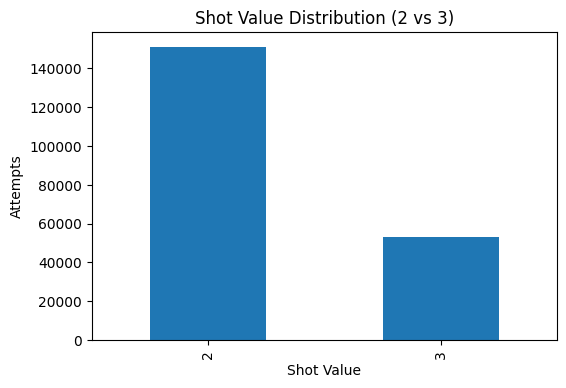

In [6]:

if 'shotValue' in shots:
    vc = shots['shotValue'].value_counts().sort_index()
    fig = plt.figure(figsize=(6,4))
    vc.plot(kind='bar')
    plt.title("Shot Value Distribution (2 vs 3)")
    plt.xlabel("Shot Value")
    plt.ylabel("Attempts")
    plt.show()
else:
    print("Column 'shotValue' not found; skipping this chart.")


## 4. Shot Distance Distribution

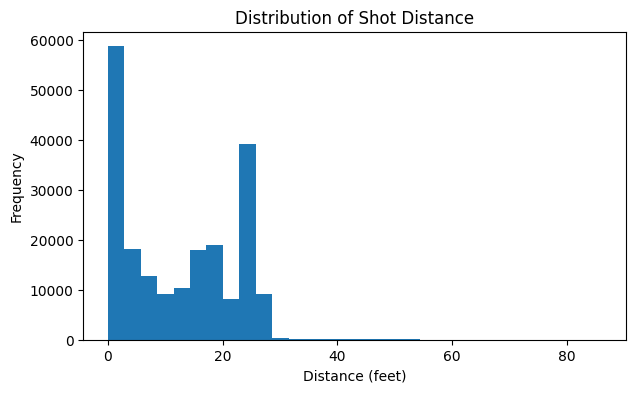

In [7]:

col = 'shot_distance' if 'shot_distance' in shots else ('shotDistance' if 'shotDistance' in shots else None)
if col is not None:
    fig = plt.figure(figsize=(7,4))
    plt.hist(shots[col].dropna(), bins=30)
    plt.title("Distribution of Shot Distance")
    plt.xlabel("Distance (feet)")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No distance column found (expected 'shot_distance' or 'shotDistance').")


## 5. Court Shot Chart (Sampled)

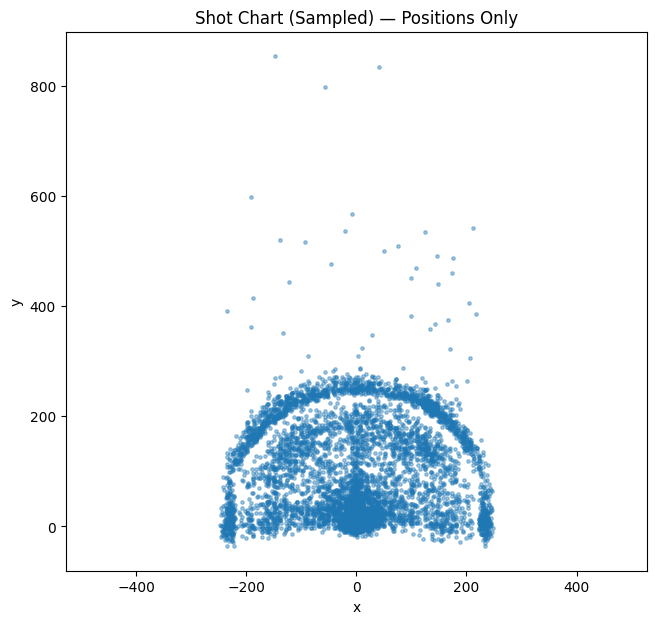

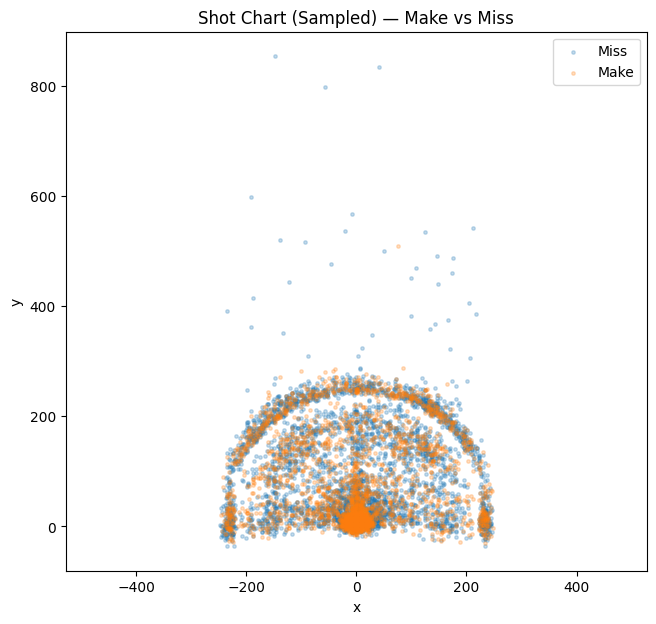

In [8]:

# For performance, sample a subset
need_cols = {'x','y','shot_made_flag'}
if need_cols.issubset(shots.columns):
    sample_n = min(7500, len(shots))
    sampled = shots.sample(sample_n, random_state=42)[['x','y','shot_made_flag']].dropna()

    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(sampled['x'], sampled['y'], s=6, alpha=0.4, label=None)
    plt.title("Shot Chart (Sampled) — Positions Only")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.show()

    # Optional: overlay make vs miss (two passes to avoid explicit colors)
    made = sampled[sampled['shot_made_flag'] == 1]
    miss = sampled[sampled['shot_made_flag'] == 0]
    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(miss['x'], miss['y'], s=6, alpha=0.25, label="Miss")
    plt.scatter(made['x'], made['y'], s=6, alpha=0.25, label="Make")
    plt.title("Shot Chart (Sampled) — Make vs Miss")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.legend()
    plt.show()
else:
    print("Columns x, y, shot_made_flag not found; skipping shot chart.")


## 6. Player FG% Leaders (min attempts filter)

Players with at least 200 attempts: 298


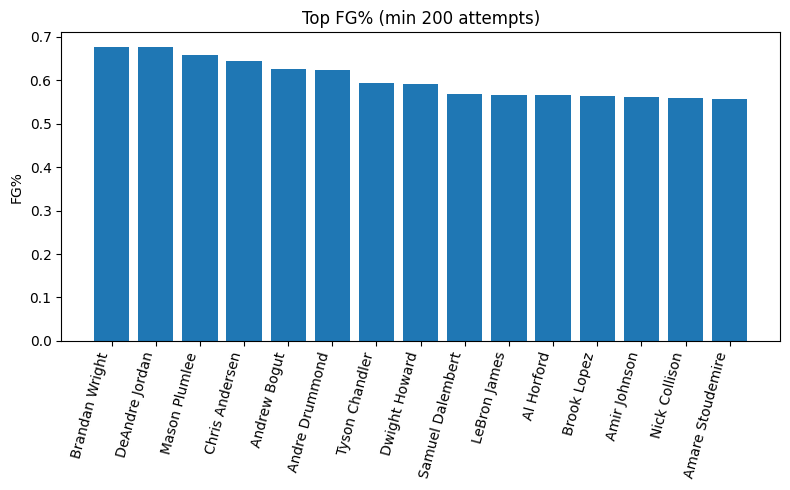

In [9]:

req = {'name','shot_made_flag'}
if req.issubset(shots.columns):
    player_stats = (
        shots.groupby('name', dropna=False)
             .agg(attempts=('shot_made_flag','size'),
                  fg_pct=('shot_made_flag','mean'))
             .reset_index()
    )
    min_att = 200
    leaders = player_stats.query('attempts >= @min_att').sort_values('fg_pct', ascending=False).head(15)
    print(f"Players with at least {min_att} attempts: {len(player_stats.query('attempts >= @min_att'))}")
    fig = plt.figure(figsize=(8,5))
    plt.bar(leaders['name'], leaders['fg_pct'])
    plt.title("Top FG% (min 200 attempts)")
    plt.ylabel("FG%")
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Columns 'name' and/or 'shot_made_flag' missing; skipping player leaders.")


## 7. FG% Heatmap — Distance × Shot Clock

/var/folders/02/8qskm_yj6gx6xyj73fgxk36h0000gp/T/ipykernel_11164/1631018474.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = shots.pivot_table(values='shot_made_flag', index=dist_cuts, columns=clock_cuts, aggfunc='mean')


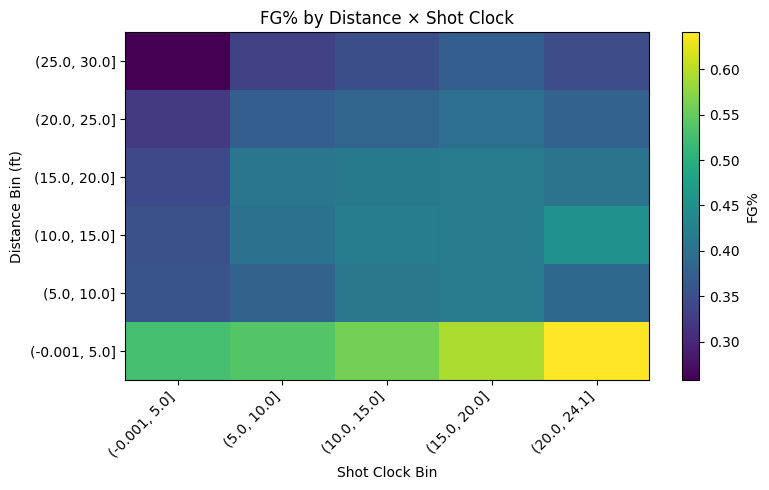

In [10]:

if {'shot_made_flag','shot_distance','shot_clock'}.issubset(shots.columns):
    # Bin distance and shot clock
    dist_bins = [0,5,10,15,20,25,30]
    clock_bins = [0,5,10,15,20,24.1]  # include 24
    dist_cuts = pd.cut(shots['shot_distance'], bins=dist_bins, include_lowest=True)
    clock_cuts = pd.cut(shots['shot_clock'], bins=clock_bins, include_lowest=True)
    pivot = shots.pivot_table(values='shot_made_flag', index=dist_cuts, columns=clock_cuts, aggfunc='mean')

    fig = plt.figure(figsize=(8,5))
    plt.imshow(pivot.values, aspect='auto', origin='lower')
    plt.title("FG% by Distance × Shot Clock")
    plt.xlabel("Shot Clock Bin")
    plt.ylabel("Distance Bin (ft)")
    plt.colorbar(label="FG%")
    plt.xticks(ticks=np.arange(len(pivot.columns)), labels=[str(c) for c in pivot.columns], rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(pivot.index)), labels=[str(i) for i in pivot.index])
    plt.tight_layout()
    plt.show()
else:
    print("Need 'shot_made_flag', 'shot_distance', and 'shot_clock'; skipping heatmap.")


## 8. Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)

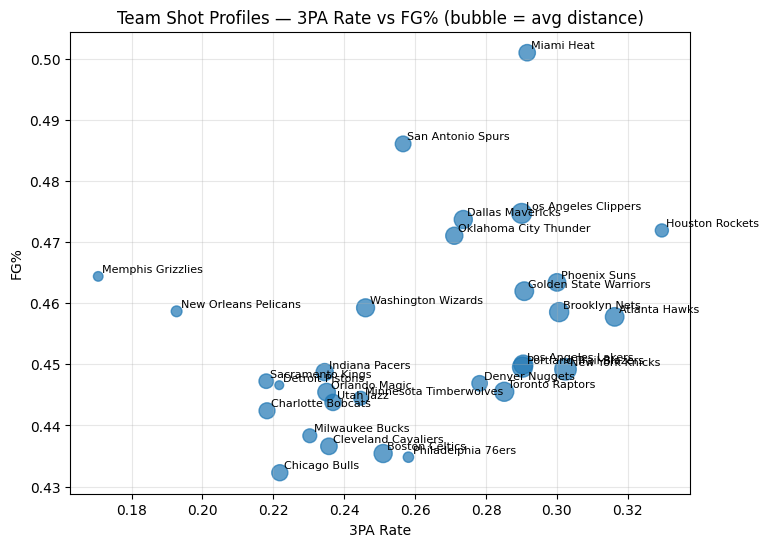

In [11]:

cols = {'team_name','shotValue','shot_made_flag','shot_distance'}
if cols.issubset(shots.columns):
    team_shots = (shots.groupby('team_name')
                         .agg(avg_dist=('shot_distance','mean'),
                              three_rate=('shotValue', lambda x: np.mean(x==3)),
                              fg_pct=('shot_made_flag','mean'))
                         .reset_index())

    fig = plt.figure(figsize=(8,6))
    sizes = 200 * (team_shots['avg_dist'] - team_shots['avg_dist'].min()) / (team_shots['avg_dist'].max() - team_shots['avg_dist'].min() + 1e-9) + 40
    plt.scatter(team_shots['three_rate'], team_shots['fg_pct'], s=sizes, alpha=0.7)
    for _, r in team_shots.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['fg_pct']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)")
    plt.xlabel("3PA Rate")
    plt.ylabel("FG%")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Missing one of ['team_name','shotValue','shot_made_flag','shot_distance']; skipping team profiles.")


## 9. Optional: Hexbin Efficiency (league-wide)

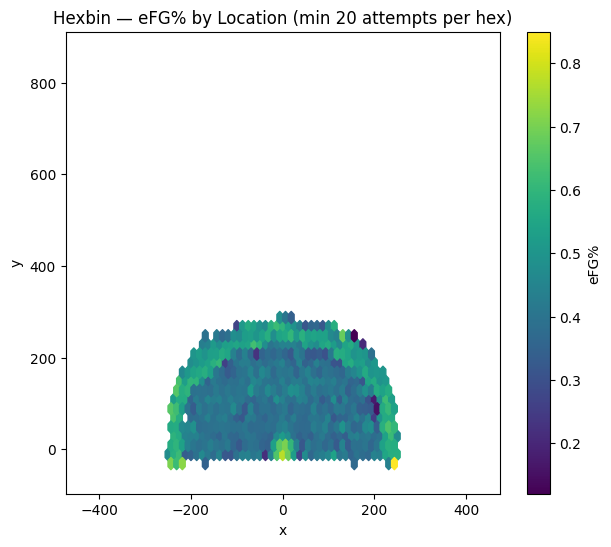

In [26]:
## Hexbin — eFG% by Location (min 20 attempts per hex)

need = {'x','y','shot_made_flag','shotValue'}
if need.issubset(shots.columns):
    # Compute per-shot contribution for eFG numerator
    shots = shots.copy()
    shots['efg_contrib'] = shots['shot_made_flag'] * (1 + 0.5*(shots['shotValue']==3))

    x = shots['x'].values
    y = shots['y'].values
    contrib = shots['efg_contrib'].values.astype(float)

    # hexbin with sum of numerator and count for denominator
    fig = plt.figure(figsize=(7,6))
    hb = plt.hexbin(
        x, y, C=contrib,
        gridsize=40,
        reduce_C_function=np.mean,  # mean of (efg_contrib / 1 per attempt)
        mincnt=20
    )
    plt.title("Hexbin — eFG% by Location (min 20 attempts per hex)")
    plt.xlabel("x")
    plt.ylabel("y")
    cb = plt.colorbar(hb)
    cb.set_label("eFG%")
    plt.axis('equal')
    plt.show()
else:
    print("Columns x, y, shot_made_flag, shotValue not found; skipping eFG% hexbin.")



## 10. Comparing Seasons (How-To)
If you have multiple seasons:
1. Load each season's CSV into a separate DataFrame and add a `season` column if missing.
2. Concatenate into one `shots_all` DataFrame.
3. Re-run the visuals grouped by `season` (e.g., filter `shots_all[shots_all['season']==2016]`).

> Tip: For A/B comparisons, compute per-team/per-player metrics per season, and then plot deltas (season B − season A).


In [13]:

# === Helper: Compute Field-Goal Points per Shot ===
if {'shot_made_flag','shotValue'}.issubset(shots.columns):
    shots = shots.copy()
    shots['fg_points'] = shots['shot_made_flag'] * shots['shotValue']
else:
    print("Missing 'shot_made_flag' or 'shotValue'; fg_points-based analyses will be skipped.")


## 11. Team 3PA Rate vs Points per Game (FG points only)

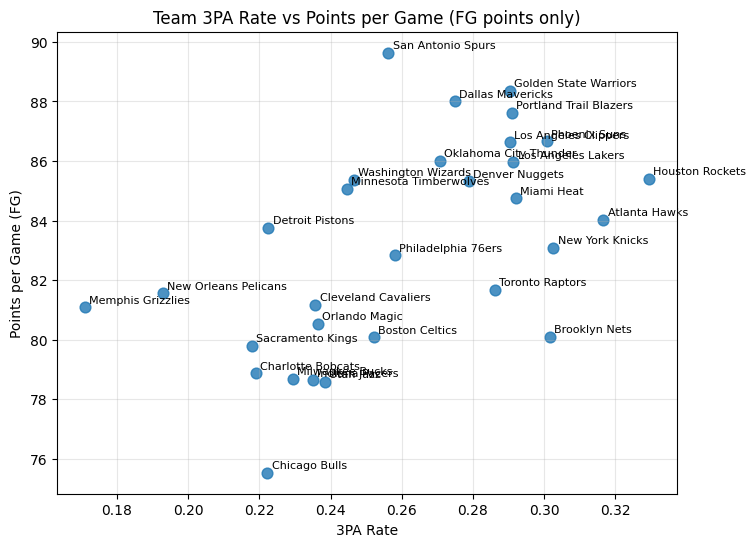

In [14]:

need = {'team_name','shotValue','shot_made_flag','espn_game_id'}
if need.issubset(shots.columns):
    # Team game-level aggregates
    team_game = (shots.groupby(['team_name','espn_game_id'])
                      .agg(fga=('shot_made_flag','size'),
                           three_att=('shotValue', lambda x: np.sum(x==3)),
                           fg_points=('fg_points','sum'))
                      .reset_index())
    # Rates
    team_game['three_rate'] = team_game['three_att'] / team_game['fga']
    # Team season averages
    team_ppg = (team_game.groupby('team_name')
                        .agg(ppg=('fg_points','mean'),
                             three_rate=('three_rate','mean'))
                        .reset_index())

    fig = plt.figure(figsize=(8,6))
    plt.scatter(team_ppg['three_rate'], team_ppg['ppg'], s=60, alpha=0.8)
    for _, r in team_ppg.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['ppg']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team 3PA Rate vs Points per Game (FG points only)")
    plt.xlabel("3PA Rate")
    plt.ylabel("Points per Game (FG)")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Need ['team_name','shotValue','shot_made_flag','espn_game_id']; skipping team 3PA vs PPG.")


## 12. Top 10 Points per Game Players (FG points only)

                  name        ppg  games
263       Kevin Durant  23.333333     81
65     Carmelo Anthony  21.467532     77
285       LeBron James  21.428571     77
424      Stephen Curry  20.064103     78
265         Kevin Love  19.350649     77
6         Al Jefferson  19.219178     73
279  LaMarcus Aldridge  18.942029     69
48       Blake Griffin  18.100000     80
195       James Harden  17.465753     73
125      Dirk Nowitzki  17.462500     80


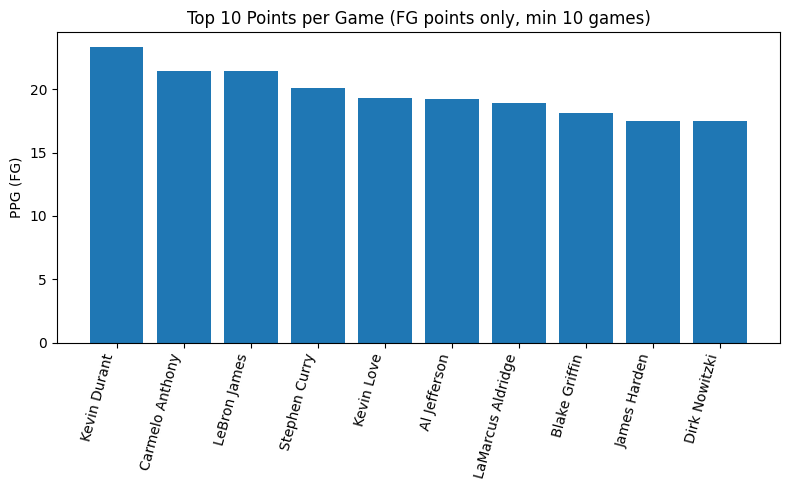

In [15]:

need = {'name','espn_game_id','fg_points'}
if need.issubset(shots.columns):
    player_game = (shots.groupby(['name','espn_game_id'])
                         .agg(points=('fg_points','sum'))
                         .reset_index())
    ppg = (player_game.groupby('name')
                    .agg(ppg=('points','mean'), games=('espn_game_id','nunique'))
                    .reset_index()
                    .query('games >= 10')  # volume filter
                    .sort_values('ppg', ascending=False)
                    .head(10))
    print(ppg)
    fig = plt.figure(figsize=(8,5))
    plt.bar(ppg['name'], ppg['ppg'])
    plt.title("Top 10 Points per Game (FG points only, min 10 games)")
    plt.ylabel("PPG (FG)")
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Need ['name','espn_game_id','fg_points']; skipping Top 10 PPG.")


## 13. Player Scatter — FG% (x) vs Shots Attempted (y)

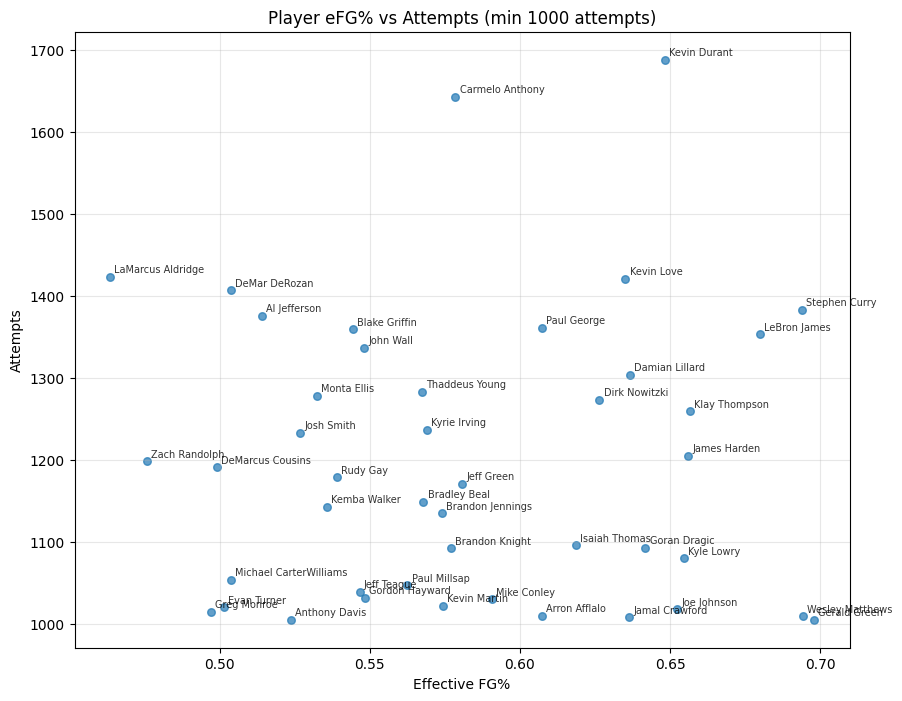

In [21]:
## Player Scatter — eFG% (x) vs Shots Attempted (y), labeled

need = {'name','shot_made_flag','shotValue'}
if need.issubset(shots.columns):
    # Compute per-player totals
    player_stats = (shots.groupby('name')
                          .agg(attempts=('shot_made_flag','size'),
                               makes=('shot_made_flag','sum'),
                               threes=('shotValue', lambda x: ((x==3)).sum() if len(x)>0 else 0))
                          .reset_index())
    
    # Effective FG% = (FGM + 0.5*3PM) / FGA
    player_stats['efg_pct'] = (player_stats['makes'] + 0.5*player_stats['threes']) / player_stats['attempts']
    
    # Apply minimum attempts filter
    player_stats = player_stats.query('attempts >= 1000')
    
    fig = plt.figure(figsize=(10,8))
    plt.scatter(player_stats['efg_pct'], player_stats['attempts'], s=30, alpha=0.7)

    # Annotate each point with player name
    for _, row in player_stats.iterrows():
        plt.annotate(row['name'],
                     (row['efg_pct'], row['attempts']),
                     xytext=(3,3),
                     textcoords='offset points',
                     fontsize=7,
                     alpha=0.8)

    plt.title("Player eFG% vs Attempts (min 1000 attempts)")
    plt.xlabel("Effective FG%")
    plt.ylabel("Attempts")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Need ['name','shot_made_flag','shotValue']; skipping eFG% vs Attempts scatter.")


## 14. Individual "Bad Shot" Percentage — Share of Contested Shots

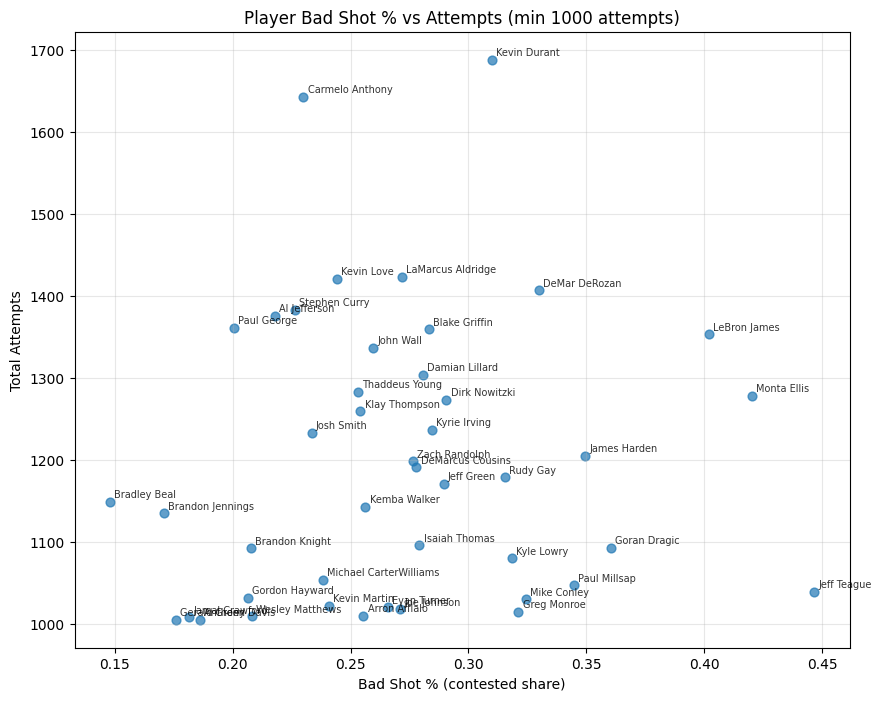

In [25]:
## Scatter — Bad Shot % (x) vs Attempts (y)

if {'name','is_contested','shot_made_flag'}.issubset(shots.columns):
    bad_pct = (shots.groupby('name')
                     .agg(attempts=('shot_made_flag','size'),
                          bad_shot_pct=('is_contested','mean'))
                     .reset_index())
    # Filter by volume
    bad_pct = bad_pct.query('attempts >= 1000')

    fig = plt.figure(figsize=(10,8))
    plt.scatter(bad_pct['bad_shot_pct'], bad_pct['attempts'], s=40, alpha=0.7)

    # Annotate each player
    for _, row in bad_pct.iterrows():
        plt.annotate(row['name'],
                     (row['bad_shot_pct'], row['attempts']),
                     xytext=(3,3),
                     textcoords='offset points',
                     fontsize=7,
                     alpha=0.8)

    plt.title("Player Bad Shot % vs Attempts (min 1000 attempts)")
    plt.xlabel("Bad Shot % (contested share)")
    plt.ylabel("Total Attempts")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Missing required columns; skipping Bad Shot % scatter.")
